In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Lifestyle_survey.csv')
df.head()

,Timestamp,Email Address,What is your age group ?,What is your gender ?,What is your current occupation ?,"On average, how many hours do you sleep per day ?",At what time do you usually go to bed ? (Ex.: 09:00 PM),How often do you engage in physical exercise ?,What type of physical activity do you perform most frequently ?,"What is your average daily screen time ? (Phone, Laptop, TV)",How often do you consume fast food ?,How much water do you drink daily ?,Do you smoke or consume alcohol ?,How often do you experience stress ?,Approximately how many hours do you work or study daily ?,How frequently do you go for health check-ups ?,How would you rate your overall health ?
0,2/19/2026 22:09:30,apurv.core@gmail.com,18–25,Male,Student,More than 8 hours,01:00 AM,1–3 days per week,"Walking, Yoga or Stretching",More than 8 hours,2–3 times per week,3–5 Litres,I do not Smoke or Drink,5,More than 8 hours,Once a month,5
1,2/19/2026 22:15:19,sanskarjain20389@gmail.com,18–25,Male,Working Professional,More than 8 hours,1 am,1–3 days per week,Sports,More than 8 hours,Once a week,1–3 Litres,Rarely,5,Less than 4 hours,Only when unwell,1
2,2/19/2026 22:17:05,dulkarmanjula@gmail.com,26–50,Female,Working Professional,7–8 hours,10:00 pm,1–3 days per week,Walking,Less than 4 hours,Once a week,3–5 Litres,I do not Smoke or Drink,1,6–8 hours,Once every 6 months,10
3,2/19/2026 22:17:59,kunalraj.s.patil@gmail.com,18–25,Male,Student,5–7 hours,23:00 PM,4–6 days per week,Gym or Strength Training,Less than 4 hours,Once a week,1–3 Litres,I do not Smoke or Drink,3,Less than 4 hours,Only when unwell,9
4,2/19/2026 22:18:23,jhapratibhajha2004@gmail.com,18–25,Female,Student,7–8 hours,11:00 pm,Daily,Walking,6–8 hours,Once a week,1–3 Litres,I do not Smoke or Drink,3,Less than 4 hours,Never,5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 17 columns):
 #   Column                                                             Non-Null Count  Dtype 
---  ------                                                             --------------  ----- 
 0   Timestamp                                                          41 non-null     object
 1   Email Address                                                      41 non-null     object
 2   What is your age group ?                                           41 non-null     object
 3   What is your gender ?                                              41 non-null     object
 4   What is your current occupation ?                                  41 non-null     object
 5   On average, how many hours do you sleep per day ?                  41 non-null     object
 6   At what time do you usually go to bed ? (Ex.: 09:00 PM)            41 non-null     object
 7   How often do you engage in physical e

In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.drop(['Timestamp', 'Email Address'], axis=1, inplace=True)

In [7]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace("?", "")
df.columns = df.columns.str.replace("(", "")
df.columns = df.columns.str.replace(")", "")
df.columns = df.columns.str.replace(",", "")
df.columns = df.columns.str.replace(" ", "_")

In [8]:
list(df.columns)

['what_is_your_age_group_',
 'what_is_your_gender_',
 'what_is_your_current_occupation_',
 'on_average_how_many_hours_do_you_sleep_per_day_',
 'at_what_time_do_you_usually_go_to_bed__ex.:_09:00_pm',
 'how_often_do_you_engage_in_physical_exercise_',
 'what_type_of_physical_activity_do_you_perform_most_frequently_',
 'what_is_your_average_daily_screen_time__phone_laptop_tv',
 'how_often_do_you_consume_fast_food_',
 'how_much_water_do_you_drink_daily_',
 'do_you_smoke_or_consume_alcohol_',
 'how_often_do_you_experience_stress_',
 'approximately_how_many_hours_do_you_work_or_study_daily_',
 'how_frequently_do_you_go_for_health_check-ups_',
 'how_would_you_rate_your_overall_health_']

In [9]:
df.rename(columns={
    'what_is_your_age_group_': 'age',
    'what_is_your_gender_': 'gender',
    'how_often_do_you_experience_stress_': 'stress_level',
    'how_would_you_rate_your_overall_health_': 'health_rating',
    'what_is_your_current_occupation_' : 'occupation',
    'on_average_how_many_hours_do_you_sleep_per_day_' : 'sleep_hours',
    'at_what_time_do_you_usually_go_to_bed__ex.:_09:00_pm' : 'bed_time',
    'how_often_do_you_engage_in_physical_exercise_' : 'exercise',
    'what_type_of_physical_activity_do_you_perform_most_frequently_' : 'type_of_exercise',
    'what_is_your_average_daily_screen_time__phone_laptop_tv' : 'screen_time',
    'how_often_do_you_consume_fast_food_' : 'fast_food',
    'how_much_water_do_you_drink_daily_': 'water_intake',
 'do_you_smoke_or_consume_alcohol_': 'smoke_alcohol',
 'how_often_do_you_experience_stress_': 'stress_level',
 'approximately_how_many_hours_do_you_work_or_study_daily_': 'work_time',
 'how_frequently_do_you_go_for_health_check-ups_': 'health_checkup',
 'how_would_you_rate_your_overall_health_' : 'health_rate'
} , inplace=True)

In [10]:
df.head()

,age,gender,occupation,sleep_hours,bed_time,exercise,type_of_exercise,screen_time,fast_food,water_intake,smoke_alcohol,stress_level,work_time,health_checkup,health_rate
0,18–25,Male,Student,More than 8 hours,01:00 AM,1–3 days per week,"Walking, Yoga or Stretching",More than 8 hours,2–3 times per week,3–5 Litres,I do not Smoke or Drink,5,More than 8 hours,Once a month,5
1,18–25,Male,Working Professional,More than 8 hours,1 am,1–3 days per week,Sports,More than 8 hours,Once a week,1–3 Litres,Rarely,5,Less than 4 hours,Only when unwell,1
2,26–50,Female,Working Professional,7–8 hours,10:00 pm,1–3 days per week,Walking,Less than 4 hours,Once a week,3–5 Litres,I do not Smoke or Drink,1,6–8 hours,Once every 6 months,10
3,18–25,Male,Student,5–7 hours,23:00 PM,4–6 days per week,Gym or Strength Training,Less than 4 hours,Once a week,1–3 Litres,I do not Smoke or Drink,3,Less than 4 hours,Only when unwell,9
4,18–25,Female,Student,7–8 hours,11:00 pm,Daily,Walking,6–8 hours,Once a week,1–3 Litres,I do not Smoke or Drink,3,Less than 4 hours,Never,5


In [11]:
df.columns

Index(['age', 'gender', 'occupation', 'sleep_hours', 'bed_time', 'exercise',
       'type_of_exercise', 'screen_time', 'fast_food', 'water_intake',
       'smoke_alcohol', 'stress_level', 'work_time', 'health_checkup',
       'health_rate'],
      dtype='object')

In [12]:
df['age'] = df['age'].str.replace("–", "-", regex=False)

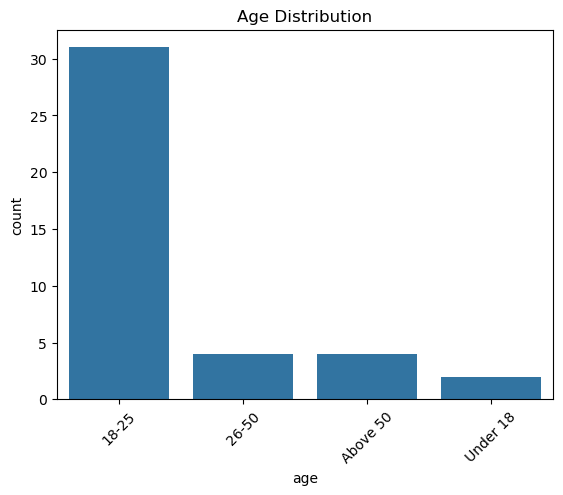

In [13]:
sns.countplot(x='age', data=df)
plt.xticks(rotation=45)
plt.title("Age Distribution")
plt.show()

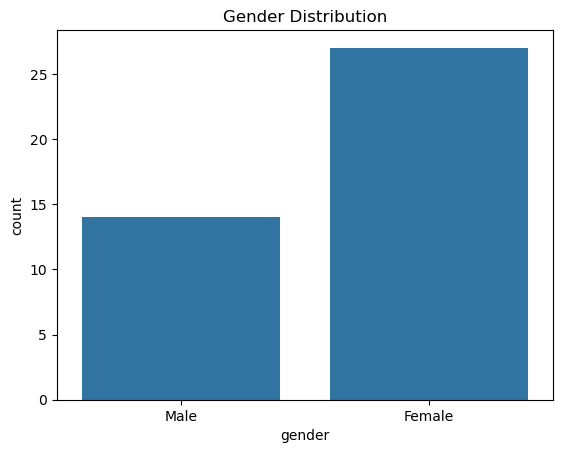

In [14]:
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

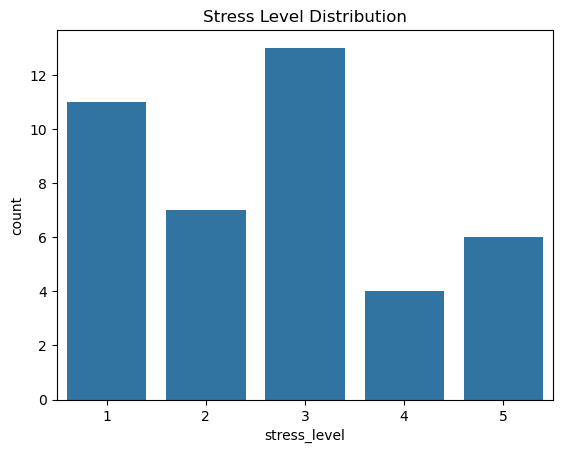

In [15]:
sns.countplot(x='stress_level', data=df)
plt.title("Stress Level Distribution")
plt.show()

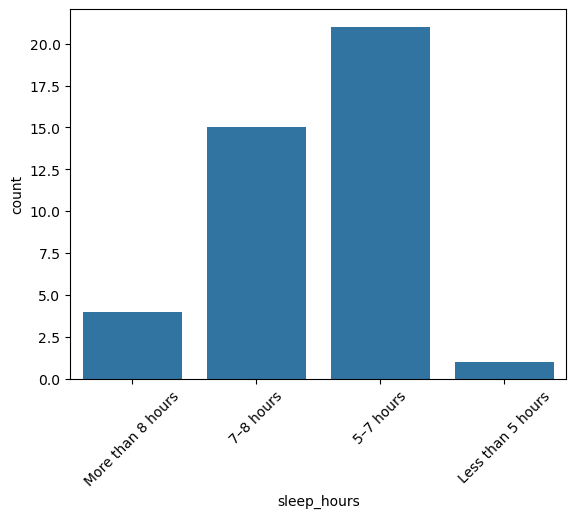

In [16]:
sns.countplot(x='sleep_hours', data=df)
plt.xticks(rotation=45)
plt.show()

In [17]:
pd.crosstab(df['sleep_hours'], df['stress_level'])

stress_level,1,2,3,4,5
sleep_hours,,,,,
5–7 hours,4,4,8,2,3
7–8 hours,6,3,4,1,1
Less than 5 hours,0,0,0,1,0
More than 8 hours,1,0,1,0,2


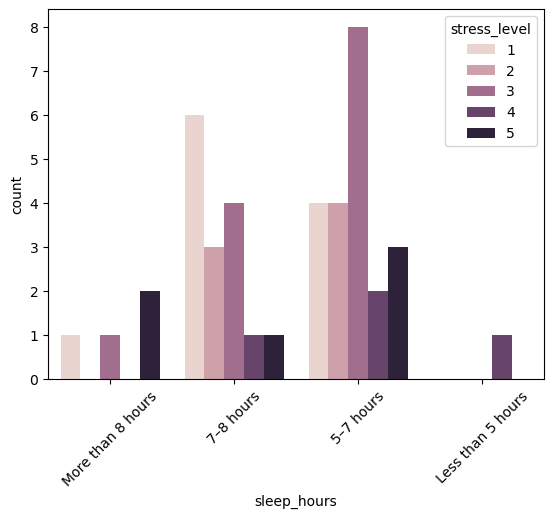

In [18]:
sns.countplot(x='sleep_hours', hue='stress_level', data=df)
plt.xticks(rotation=45)
plt.show()

In [19]:
pd.crosstab(df['screen_time'], df['stress_level'])

stress_level,1,2,3,4,5
screen_time,,,,,
4–6 hours,3,2,2,1,2
6–8 hours,2,1,2,1,0
Less than 4 hours,6,3,7,1,1
More than 8 hours,0,1,2,1,3


In [20]:
pd.crosstab(df['exercise'], df['health_rate'])

health_rate,1,3,4,5,6,7,8,9,10
exercise,,,,,,,,,
1–3 days per week,1,1,1,3,3,1,0,1,1
4–6 days per week,1,0,0,1,0,0,2,1,0
Daily,0,0,0,2,1,0,6,2,4
Never,1,1,2,3,0,1,1,0,0


In [21]:
pd.crosstab(df['smoke_alcohol'], df['stress_level'])

stress_level,1,2,3,4,5
smoke_alcohol,,,,,
Frequently,0,0,1,0,0
I do not Smoke or Drink,11,6,12,3,5
Occasionally,0,1,0,0,0
Rarely,0,0,0,0,1
Regularly,0,0,0,1,0


In [22]:
pd.crosstab(df['work_time'], df['stress_level'])

stress_level,1,2,3,4,5
work_time,,,,,
4–6 hours,2,4,2,0,1
6–8 hours,3,0,3,2,2
Less than 4 hours,4,1,6,1,2
More than 8 hours,2,2,2,1,1


In [23]:
df.isnull().sum()

age                 0
gender              0
occupation          0
sleep_hours         0
bed_time            0
exercise            0
type_of_exercise    0
screen_time         0
fast_food           0
water_intake        0
smoke_alcohol       0
stress_level        0
work_time           0
health_checkup      0
health_rate         0
dtype: int64

In [24]:
X = df.drop('stress_level', axis=1)
y = df['stress_level']

In [25]:
X = pd.get_dummies(X, drop_first=True)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.3333333333333333
              precision    recall  f1-score   support

           1       0.50      0.67      0.57         3
           2       0.50      1.00      0.67         1
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         2

    accuracy                           0.33         9
   macro avg       0.20      0.33      0.25         9
weighted avg       0.22      0.33      0.26         9



C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
